### Exploratory Data Analysis – Table Detection & Classification

##### Imports & Configuration

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random

DATASET_DIR = Path("../data/raw/data")
CLASSES = ["need_cleaning", "free", "occupied", "awaiting"]

##### Dataset Structure Validation

In [25]:
for cls in CLASSES:
    img_dir = DATASET_DIR / cls / "images"
    lbl_dir = DATASET_DIR / cls / "labels"
    
    print(f"- {cls}:")
    print("\t + images exists:", img_dir.exists())
    print("\t + labels exists:", lbl_dir.exists(), '\n')

- need_cleaning:
	 + images exists: True
	 + labels exists: True 

- free:
	 + images exists: True
	 + labels exists: True 

- occupied:
	 + images exists: True
	 + labels exists: True 

- awaiting:
	 + images exists: True
	 + labels exists: True 



##### Number of Images per Class

In [27]:
image_counts = {}

for cls in CLASSES:
    images = list((DATASET_DIR / cls / "images").glob("*"))
    image_counts[cls] = len(images)

for name, count in image_counts.items():
    print(f"- {name :17s} -> {count}")

- need_cleaning     -> 274
- free              -> 276
- occupied          -> 62
- awaiting          -> 36


##### Histogram: Number of Images per Class

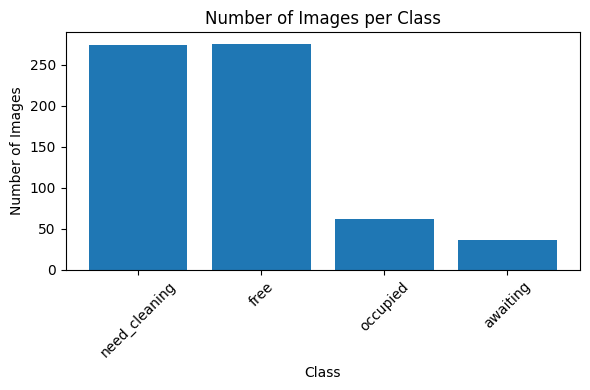

In [51]:
plt.figure(figsize=(6, 4))
plt.bar(image_counts.keys(), image_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Total Number of images

In [31]:
total = 0
for _, count in image_counts.items():
    total += count

print(f"- {'Total' :17s} -> {total}")

- Total             -> 648


##### Number of Labels per Class

In [33]:
label_counts = {}

for cls in CLASSES:
    labels = list((DATASET_DIR / cls / "labels").glob("*.txt"))
    label_counts[cls] = len(labels)

for name, count in label_counts.items():
    print(f"- {name :17s} -> {count}")

- need_cleaning     -> 0
- free              -> 0
- occupied          -> 0
- awaiting          -> 0


##### Histogram: Number of Labels per Class

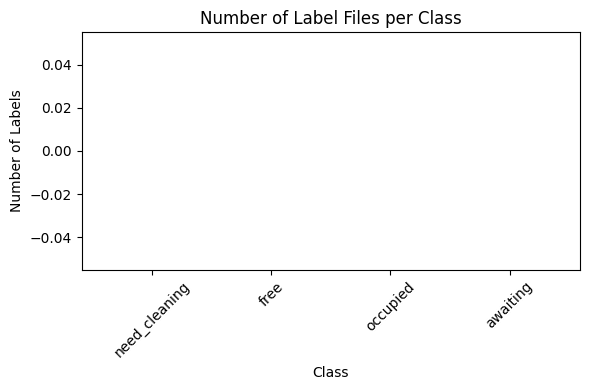

In [52]:
plt.figure(figsize=(6, 4))
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Number of Label Files per Class")
plt.xlabel("Class")
plt.ylabel("Number of Labels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Images Without Labels

In [34]:
images_without_labels = []

for cls in CLASSES:
    img_dir = DATASET_DIR / cls / "images"
    lbl_dir = DATASET_DIR / cls / "labels"
    
    for img_path in img_dir.glob("*"):
        label_path = lbl_dir / img_path.with_suffix(".txt").name
        if not label_path.exists():
            images_without_labels.append(img_path)

len(images_without_labels)

648

##### Percentage of Images Without Labels

In [41]:
total_images = sum(image_counts.values())
missing_label_ratio = len(images_without_labels) / total_images * 100

print(f"Percentage: {missing_label_ratio :.2f}%")

Percentage: 100.00%


##### Empty Label Files

In [42]:
empty_label_files = []

for cls in CLASSES:
    for lbl_file in (DATASET_DIR / cls / "labels").glob("*.txt"):
        if lbl_file.stat().st_size == 0:
            empty_label_files.append(lbl_file)

len(empty_label_files)

0

##### Image Resolution Analysis

In [45]:
image_sizes = set()

for cls in CLASSES:
    images = list((DATASET_DIR / cls / "images").glob("*"))
    for img_path in images:
        with Image.open(img_path) as img:
            image_sizes.add(img.size)

print("Number of different resolutions:", len(image_sizes))

Number of different resolutions: 248


##### Corrupted or Unreadable Images

In [46]:
corrupted_images = []

for cls in CLASSES:
    for img_path in (DATASET_DIR / cls / "images").glob("*"):
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted_images.append(img_path)

len(corrupted_images)

0

##### Bounding Box Area Distribution
Check if objects are too small or too large

In [ ]:
box_areas = []

for cls in CLASSES:
    for lbl_file in (DATASET_DIR / cls / "labels").glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                _, x, y, w, h = map(float, line.split())
                box_areas.append(w * h)

np.percentile(box_areas, [5, 25, 50, 75, 95])

##### Visual Sanity Check: Images + Bounding Boxes

In [57]:
def plot_image_with_boxes(img_path, label_path, index = 1):
    img = Image.open(img_path)
    w, h = img.size
    
    plt.subplot(2, 2, index)

    plt.imshow(img)
    
    if label_path.exists():
        for line in open(label_path):
            _, xc, yc, bw, bh = map(float, line.split())
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w
            y2 = (yc + bh / 2) * h
            plt.gca().add_patch(
                plt.Rectangle((x1, y1), x2-x1, y2-y1,
                              fill=False, edgecolor='red', linewidth=2)
            )
    plt.axis("off")

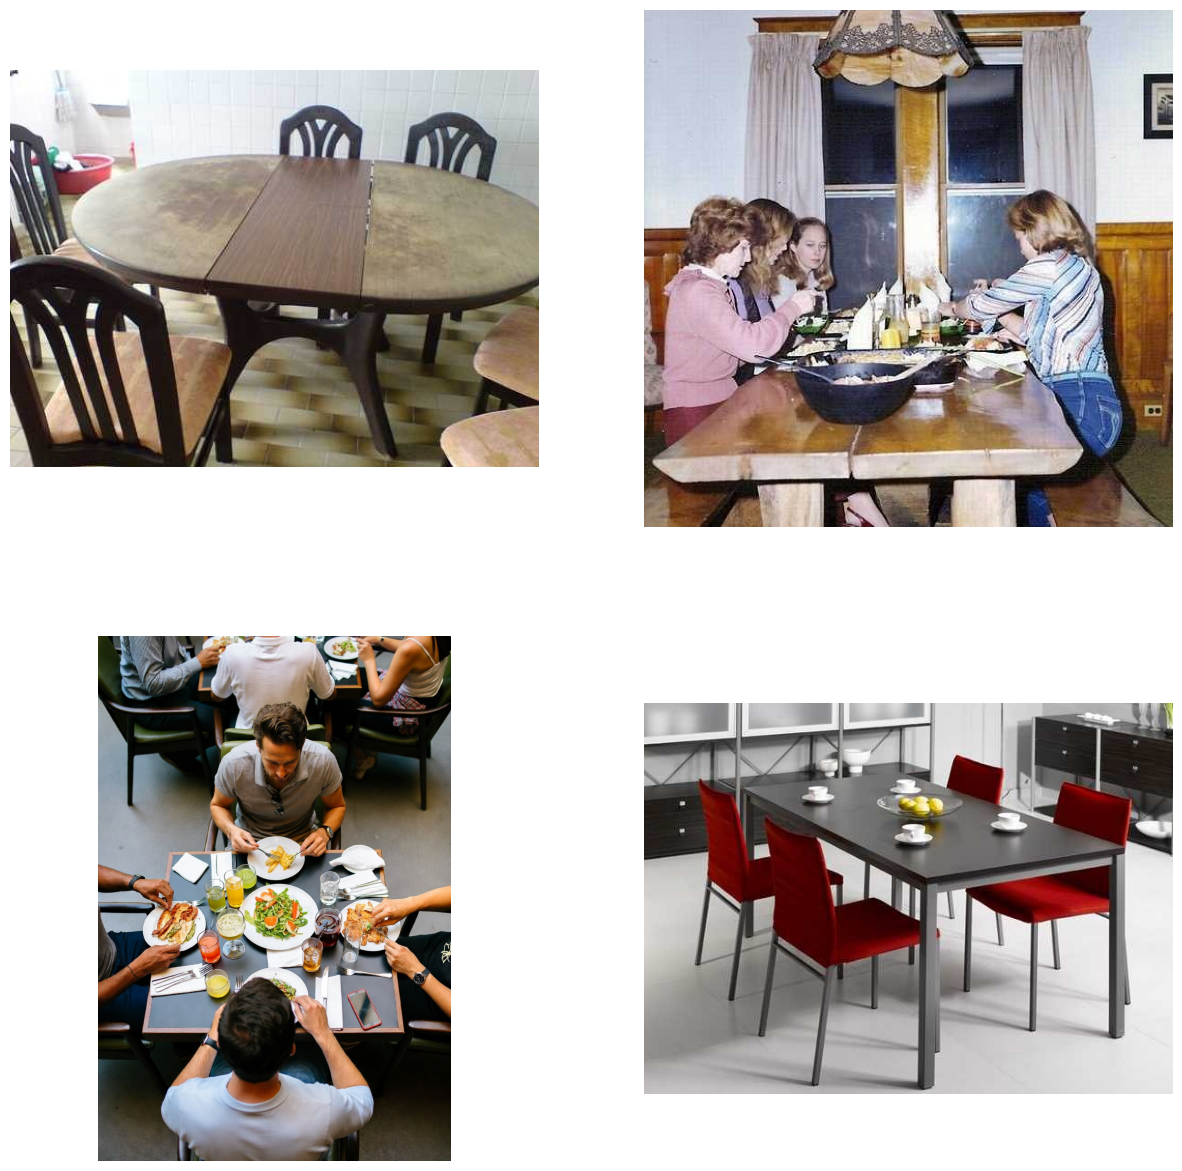

In [65]:
plt.figure(figsize=(15, 15))

for i in range(1, 5):
    
    cls = random.choice(CLASSES)
    img_path = random.choice(list((DATASET_DIR / cls / "images").glob("*")))
    label_path = DATASET_DIR / cls / "labels" / img_path.with_suffix(".txt").name

    plot_image_with_boxes(img_path, label_path, i)

plt.show()